<a href="https://colab.research.google.com/github/saicharan-allala/5.2/blob/main/project(ml).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
df = pd.read_csv("/content/Dataset of Diabetes .csv")
test_samples = [0.1,0.2,0.3]
df

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,200,454317,M,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y
996,671,876534,M,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,Y
997,669,87654,M,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,Y
998,99,24004,M,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,Y


In [3]:
from sklearn.preprocessing import LabelEncoder
l = LabelEncoder()
for i in df.columns:
  df[i] = l.fit_transform(df[i])
x = df.drop("CLASS",axis=1)
y = df["CLASS"]
print(x)
print(y)

      ID  No_Pation  Gender  AGE  Urea  Cr  HbA1c  Chol  TG  HDL  LDL  VLDL  \
0    501        131       0   23    37  26     12    25   5   32   15     4   
1    734        316       1    2    34  42     12    20  11   13   25     5   
2    419        810       0   23    37  26     12    25   5   32   15     4   
3    679        887       0   23    37  26     12    25   5   32   15     4   
4    503        318       1    7    64  26     12    32   6    6   23     3   
..   ...        ...     ...  ...   ...  ..    ...   ...  ..  ...  ...   ...   
995  199        923       1   44    91  76     33    59  14   14   20     5   
996  670        948       1    5    15  40     87    24  21    4   28    48   
997  668        885       1    4    64  61     30    24   7   14   28    37   
998   98        183       1   11    49  39     30    36  18   20   33    46   
999  247        233       1   27    40  47     32    21  14   13   34     6   

     BMI  
0      9  
1      7  
2      9  
3      

In [4]:
from sklearn.preprocessing import MinMaxScaler
m = MinMaxScaler()
x = m.fit_transform(x)
print(x)
print(y)

[[0.62703379 0.13645833 0.         ... 0.234375   0.06779661 0.14285714]
 [0.91864831 0.32916667 0.5        ... 0.390625   0.08474576 0.11111111]
 [0.52440551 0.84375    0.         ... 0.234375   0.06779661 0.14285714]
 ...
 [0.83604506 0.921875   0.5        ... 0.4375     0.62711864 0.3015873 ]
 [0.12265332 0.190625   0.5        ... 0.515625   0.77966102 0.95238095]
 [0.30913642 0.24270833 0.5        ... 0.53125    0.10169492 0.6031746 ]]
0      0
1      0
2      0
3      0
4      0
      ..
995    3
996    4
997    4
998    4
999    4
Name: CLASS, Length: 1000, dtype: int64


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

test_accuracy = []
train_accuracy = []

cm1 = cm2 = cm3 = None

for index, i in enumerate(test_samples):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=20)

    l = LogisticRegression()
    trained_model = l.fit(x_train, y_train)

    ypred = trained_model.predict(x_test)
    y_pred = trained_model.predict(x_train)

    accuracy = accuracy_score(y_test, ypred)
    accuracy1 = accuracy_score(y_train, y_pred)
    test_accuracy.append(accuracy)
    train_accuracy.append(accuracy1)

    cm = confusion_matrix(y_test, ypred)

    if index == 0:
        cm1 = cm
    elif index == 1:
        cm2 = cm
    elif index == 2:
        cm3 = cm

    print("Test Size:", i)
    print("Test Accuracy:", accuracy)
    print("Train Accuracy:", accuracy1)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, ypred))

Test Size: 0.1
Test Accuracy: 0.9
Train Accuracy: 0.9155555555555556
Confusion Matrix:
 [[ 7  0  1]
 [ 3  0  5]
 [ 1  0 83]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.88      0.74         8
           2       0.00      0.00      0.00         8
           3       0.93      0.99      0.96        84

    accuracy                           0.90       100
   macro avg       0.52      0.62      0.57       100
weighted avg       0.83      0.90      0.86       100

Test Size: 0.2
Test Accuracy: 0.91
Train Accuracy: 0.915
Confusion Matrix:
 [[ 18   0   2]
 [  5   0   8]
 [  2   1 164]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.90      0.80        20
           2       0.00      0.00      0.00        13
           3       0.94      0.98      0.96       167

    accuracy                           0.91       200
   macro avg       0.55      0.63      0.59       20

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


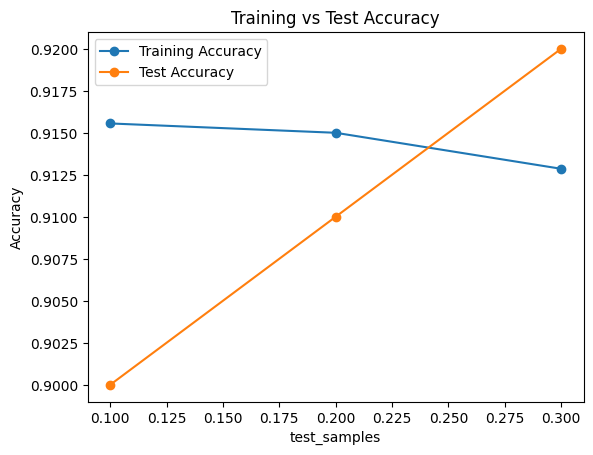

In [6]:
import matplotlib.pyplot as plt

plt.plot(test_samples, train_accuracy, marker='o', label='Training Accuracy')
plt.plot(test_samples, test_accuracy, marker='o', label='Test Accuracy')

plt.xlabel("test_samples")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy")

plt.legend()
plt.show()



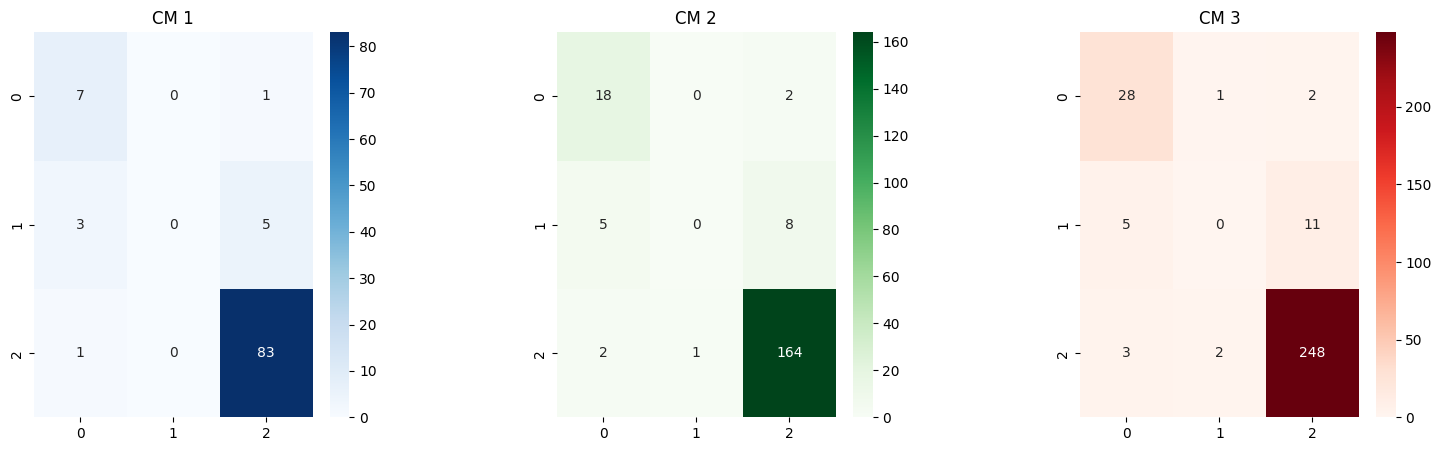

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("CM 1")

sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("CM 2")

sns.heatmap(cm3, annot=True, fmt='d', cmap='Reds', ax=axes[2])
axes[2].set_title("CM 3")

plt.subplots_adjust(wspace=0.5)

plt.show()

In [8]:
print("------SUPPORT VECTOR MACHINE---------")
from sklearn.svm import SVC
for i in test_samples:
  x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=20)
  sm = SVC()
  trained_model= sm.fit(x_train,y_train)
  ypred = trained_model.predict(x_test)
  y_pred = trained_model.predict(x_train)
  print("Test Size:",i)
  print("test_Accuracy Score:", accuracy_score(y_test,ypred))
  print("train_Accuracy Score:",accuracy_score(y_train,y_pred))
  print("Confusion Matrix:\n", confusion_matrix(y_test,ypred))
  print("Classification Report:\n", classification_report(y_test,ypred))


------SUPPORT VECTOR MACHINE---------
Test Size: 0.1
test_Accuracy Score: 0.91
train_Accuracy Score: 0.9488888888888889
Confusion Matrix:
 [[ 7  0  1]
 [ 3  2  3]
 [ 1  1 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.88      0.74         8
           2       0.67      0.25      0.36         8
           3       0.95      0.98      0.96        84

    accuracy                           0.91       100
   macro avg       0.75      0.70      0.69       100
weighted avg       0.91      0.91      0.90       100

Test Size: 0.2
test_Accuracy Score: 0.93
train_Accuracy Score: 0.955
Confusion Matrix:
 [[ 19   0   1]
 [  4   4   5]
 [  2   2 163]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.95      0.84        20
           2       0.67      0.31      0.42        13
           3       0.96      0.98      0.97       167

    accuracy                           0.93

In [9]:
accracy1 = []
accracy2 = []
accracy3 = []
accracy4 = []
accracy5 = []
accracy6 = []
print("-------- Linear Svm kernaling --------")
for index,i in enumerate(test_samples):
  x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=20)
  sm = SVC(kernel='linear')
  trained_model= sm.fit(x_train,y_train)
  ypred = trained_model.predict(x_test)
  y_pred = trained_model.predict(x_train)
  accracy1.append(accuracy_score(y_test,ypred))
  accracy2.append(accuracy_score(y_train,y_pred))
  print("Test Size:",i)
  print("test_Accuracy Score:", accuracy_score(y_test,ypred))
  print("train_Accuracy Score:",accuracy_score(y_train,y_pred))
  print("Confusion Matrix:\n", confusion_matrix(y_test,ypred))
  print("Classification Report:\n", classification_report(y_test,ypred))
print("-------- polynomial Svm kernaling --------")
for index,i in enumerate(test_samples):
  x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=20)
  sm = SVC(kernel='poly')
  trained_model= sm.fit(x_train,y_train)
  ypred = trained_model.predict(x_test)
  y_pred = trained_model.predict(x_train)
  accracy3.append(accuracy_score(y_test,ypred))
  accracy4.append(accuracy_score(y_train,y_pred))
  print("Test Size:",i)
  print("test_Accuracy Score:", accuracy_score(y_test,ypred))
  print("train_Accuracy Score:",accuracy_score(y_train,y_pred))
  print("Confusion Matrix:\n", confusion_matrix(y_test,ypred))
  print("Classification Report:\n", classification_report(y_test,ypred))
print("-------- rbf Svm kernaling --------")
for index,i in enumerate(test_samples):
  x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=20)
  sm = SVC(kernel='rbf')
  trained_model= sm.fit(x_train,y_train)
  ypred = trained_model.predict(x_test)
  y_pred = trained_model.predict(x_train)
  accracy5.append(accuracy_score(y_test,ypred))
  accracy6.append(accuracy_score(y_train,y_pred))
  print("Test Size:",i)
  print("test_Accuracy Score:", accuracy_score(y_test,ypred))
  print("train_Accuracy Score:",accuracy_score(y_train,y_pred))
  print("Confusion Matrix:\n", confusion_matrix(y_test,ypred))
  print("Classification Report:\n", classification_report(y_test,ypred))

-------- Linear Svm kernaling --------
Test Size: 0.1
test_Accuracy Score: 0.91
train_Accuracy Score: 0.9155555555555556
Confusion Matrix:
 [[ 8  0  0]
 [ 3  0  5]
 [ 1  0 83]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         8
           2       0.00      0.00      0.00         8
           3       0.94      0.99      0.97        84

    accuracy                           0.91       100
   macro avg       0.54      0.66      0.59       100
weighted avg       0.85      0.91      0.87       100

Test Size: 0.2
test_Accuracy Score: 0.91
train_Accuracy Score: 0.91625
Confusion Matrix:
 [[ 19   0   1]
 [  5   0   8]
 [  4   0 163]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.95      0.79        20
           2       0.00      0.00      0.00        13
           3       0.95      0.98      0.96       167

    accuracy                           0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Test Size: 0.3
test_Accuracy Score: 0.9233333333333333
train_Accuracy Score: 0.9842857142857143
Confusion Matrix:
 [[ 25   3   3   0]
 [  3   7   6   0]
 [  4   3 245   1]
 [  0   0   0   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79        31
           2       0.54      0.44      0.48        16
           3       0.96      0.97      0.97       253
           4       0.00      0.00      0.00         0

    accuracy                           0.92       300
   macro avg       0.57      0.55      0.56       300
weighted avg       0.92      0.92      0.92       300

-------- rbf Svm kernaling --------
Test Size: 0.1
test_Accuracy Score: 0.91
train_Accuracy Score: 0.9488888888888889
Confusion Matrix:
 [[ 7  0  1]
 [ 3  2  3]
 [ 1  1 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.88      0.74         8
           2       0.67      0.25      0.3

In [ ]:
from imblearn.over_sampling import RandomOverSampler

s = RandomOverSampler(random_state=20)
x2,y2 = s.fit_resample(x,y)
accracy1 = []
accracy2 = []
accracy3 = []
accracy4 = []
accracy5 = []
accracy6 = []
print("-------- Linear Svm kernaling --------")
for index,i in enumerate(test_samples):
  x_train,x_test,y_train,y_test = train_test_split(x2,y2,test_size=i,random_state=20)
  sm = SVC(kernel='linear')
  trained_model= sm.fit(x_train,y_train)
  ypred = trained_model.predict(x_test)
  y_pred = trained_model.predict(x_train)
  accracy1.append(accuracy_score(y_test,ypred))
  accracy2.append(accuracy_score(y_train,y_pred))
  print("Test Size:",i)
  print("test_Accuracy Score:", accuracy_score(y_test,ypred))
  print("train_Accuracy Score:",accuracy_score(y_train,y_pred))
  print("Confusion Matrix:\n", confusion_matrix(y_test,ypred))
  print("Classification Report:\n", classification_report(y_test,ypred))
print("-------- polynomial Svm kernaling --------")
for index,i in enumerate(test_samples):
  x_train,x_test,y_train,y_test = train_test_split(x2,y2,test_size=i,random_state=20)
  sm = SVC(kernel='poly')
  trained_model= sm.fit(x_train,y_train)
  ypred = trained_model.predict(x_test)
  y_pred = trained_model.predict(x_train)
  accracy3.append(accuracy_score(y_test,ypred))
  accracy4.append(accuracy_score(y_train,y_pred))
  print("Test Size:",i)
  print("test_Accuracy Score:", accuracy_score(y_test,ypred))
  print("train_Accuracy Score:",accuracy_score(y_train,y_pred))
  print("Confusion Matrix:\n", confusion_matrix(y_test,ypred))
  print("Classification Report:\n", classification_report(y_test,ypred))
print("-------- rbf Svm kernaling --------")
for index,i in enumerate(test_samples):
  x_train,x_test,y_train,y_test = train_test_split(x2,y2,test_size=i,random_state=20)
  sm = SVC(kernel='rbf')
  trained_model= sm.fit(x_train,y_train)
  ypred = trained_model.predict(x_test)
  y_pred = trained_model.predict(x_train)
  accracy5.append(accuracy_score(y_test,ypred))
  accracy6.append(accuracy_score(y_train,y_pred))
  print("Test Size:",i)
  print("test_Accuracy Score:", accuracy_score(y_test,ypred))
  print("train_Accuracy Score:",accuracy_score(y_train,y_pred))
  print("Confusion Matrix:\n", confusion_matrix(y_test,ypred))
  print("Classification Report:\n", classification_report(y_test,ypred))


-------- Linear Svm kernaling --------
Test Size: 0.1
test_Accuracy Score: 0.9214285714285714
train_Accuracy Score: 0.9391534391534392
Confusion Matrix:
 [[77  4  6  0  0]
 [ 0 78  0  0  0]
 [ 0  5 73  0  0]
 [ 3  0  7 75  8]
 [ 0  0  0  0 84]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92        87
           1       0.90      1.00      0.95        78
           2       0.85      0.94      0.89        78
           3       1.00      0.81      0.89        93
           4       0.91      1.00      0.95        84

    accuracy                           0.92       420
   macro avg       0.92      0.93      0.92       420
weighted avg       0.93      0.92      0.92       420



In [ ]:
from sklearn.model_selection import KFold
import numpy as np
from math import sqrt
kfold = KFold(n_splits=5, shuffle=True, random_state=20)
accuracies = []
for train_index,test_index in kfold.split(x):
  x_train, x_test = x[train_index], x[test_index]
  y_train, y_test = y[train_index], y[test_index]
  sm = SVC()
  trained_model = sm.fit(x_train,y_train)
  y_pred = trained_model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)
  print(classification_report(y_test, y_pred))
  print(accuracies)
mean_actual = np.mean(accuracies)
std_actual = np.std(accuracies)
standard_error = std_actual / np.sqrt(5)
print(standard_error)

In [ ]:
n_iterations = 50
accuracies_lr = []
from sklearn.utils import resample

for i in range(n_iterations):
    X_boot, y_boot = resample(x, y, replace=True, random_state=i)

    X_train, X_test, y_train, y_test = train_test_split(
        X_boot, y_boot, test_size=0.3, random_state=i)

    sm = SVC()
    trained_model=sm.fit(X_train, y_train)

    y_pred = trained_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_lr.append(acc)
print(accuracies_lr)

In [ ]:
#REgularization (l1)
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

test_accuracy = []
train_accuracy = []

cm1 = cm2 = cm3 = None

for index, i in enumerate(test_samples):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=20)

    l = LogisticRegression(penalty="l1",solver="liblinear")
    trained_model = l.fit(x_train, y_train)

    ypred = trained_model.predict(x_test)
    y_pred = trained_model.predict(x_train)

    accuracy = accuracy_score(y_test, ypred)
    accuracy1 = accuracy_score(y_train, y_pred)
    test_accuracy.append(accuracy)
    train_accuracy.append(accuracy1)

    cm = confusion_matrix(y_test, ypred)

    if index == 0:
        cm1 = cm
    elif index == 1:
        cm2 = cm
    elif index == 2:
        cm3 = cm

    print("Test Size:", i)
    print("Test Accuracy:", accuracy)
    print("Train Accuracy:", accuracy1)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, ypred))

import matplotlib.pyplot as plt

plt.plot(test_samples, train_accuracy, marker='o', label='Training Accuracy')
plt.plot(test_samples, test_accuracy, marker='o', label='Test Accuracy')

plt.xlabel("test_samples")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy")

plt.legend()
plt.show()




In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("CM 1")

sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("CM 2")

sns.heatmap(cm3, annot=True, fmt='d', cmap='Reds', ax=axes[2])
axes[2].set_title("CM 3")

plt.subplots_adjust(wspace=0.5)

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

test_accuracy = []
train_accuracy = []

cm1 = cm2 = cm3 = None

for index, i in enumerate(test_samples):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=20)

    l = LogisticRegression(penalty="l2",solver="liblinear")
    trained_model = l.fit(x_train, y_train)

    ypred = trained_model.predict(x_test)
    y_pred = trained_model.predict(x_train)

    accuracy = accuracy_score(y_test, ypred)
    accuracy1 = accuracy_score(y_train, y_pred)
    test_accuracy.append(accuracy)
    train_accuracy.append(accuracy1)

    cm = confusion_matrix(y_test, ypred)

    if index == 0:
        cm1 = cm
    elif index == 1:
        cm2 = cm
    elif index == 2:
        cm3 = cm

    print("Test Size:", i)
    print("Test Accuracy:", accuracy)
    print("Train Accuracy:", accuracy1)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, ypred))
import matplotlib.pyplot as plt

plt.plot(test_samples, train_accuracy, marker='o', label='Training Accuracy')
plt.plot(test_samples, test_accuracy, marker='o', label='Test Accuracy')

plt.xlabel("test_samples")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy")

plt.legend()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("CM 1")

sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("CM 2")

sns.heatmap(cm3, annot=True, fmt='d', cmap='Reds', ax=axes[2])
axes[2].set_title("CM 3")

plt.subplots_adjust(wspace=0.5)

plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

test_accuracy = []
train_accuracy = []

cm1 = cm2 = cm3 = None

for index, i in enumerate(test_samples):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=20)

    l = SVC(kernel='rbf', C=1.0)
    trained_model = l.fit(x_train, y_train)

    ypred = trained_model.predict(x_test)
    y_pred = trained_model.predict(x_train)

    accuracy = accuracy_score(y_test, ypred)
    accuracy1 = accuracy_score(y_train, y_pred)
    test_accuracy.append(accuracy)
    train_accuracy.append(accuracy1)

    cm = confusion_matrix(y_test, ypred)

    if index == 0:
        cm1 = cm
    elif index == 1:
        cm2 = cm
    elif index == 2:
        cm3 = cm

    print("Test Size:", i)
    print("Test Accuracy:", accuracy)
    print("Train Accuracy:", accuracy1)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, ypred))



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

test_accuracy = []
train_accuracy = []

cm1 = cm2 = cm3 = None

for index, i in enumerate(test_samples):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=20)

    l = LinearSVC(penalty='l1')
    trained_model = l.fit(x_train, y_train)

    ypred = trained_model.predict(x_test)
    y_pred = trained_model.predict(x_train)

    accuracy = accuracy_score(y_test, ypred)
    accuracy1 = accuracy_score(y_train, y_pred)
    test_accuracy.append(accuracy)
    train_accuracy.append(accuracy1)

    cm = confusion_matrix(y_test, ypred)

    if index == 0:
        cm1 = cm
    elif index == 1:
        cm2 = cm
    elif index == 2:
        cm3 = cm

    print("Test Size:", i)
    print("Test Accuracy:", accuracy)
    print("Train Accuracy:", accuracy1)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, ypred))



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy=[]
for index, i in enumerate(range(1,100),start=1):
  x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=20)
  knn = KNeighborsClassifier(n_neighbors=i)
  trained_model = knn.fit(x_train,y_train)
  ypred = trained_model.predict(x_test)
  test_accuracy = accuracy_score(y_test,ypred)
  print(f"the valueis k = {index} where accuracy is {test_accuracy}")
  accuracy.append(test_accuracy)
best_acc = max(accuracy)
best_k = accuracy.index(best_acc) + 1
print("\nBest Accuracy:", best_acc)
print("Best k:", best_k)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=20)
knn = KNeighborsClassifier(n_neighbors=11)
trained_model = knn.fit(x_train,y_train)
ypred = trained_model.predict(x_test)
y_pred = trained_model.predict(x_train)
test_accuracy = accuracy_score(y_test,ypred)
train_accuracy = accuracy_score(y_train,y_pred)
c = confusion_matrix(y_test,ypred)
performance = classification_report(y_test,ypred)
print("Test Accuracy:", test_accuracy)
print("Train Accuracy:", train_accuracy)
print("Confusion Matrix:\n", c)
print("Classification Report:\n", performance)